# Sample Code for the Creep Properties Dataset

This notebook provides Python code for loading the dataset.

The code was developed as a supplementary material for the following manuscript:

* Isshu Lee, John W. Merickel, Boopathy Kombaiah, Yalei Tang, Fei Xu, Rongjie Song, Aleksandar Vakanski, "Compilation of Creep Property Data for Nuclear Structural Materials," *Scientific Data*, 2025.

The dataset is stored in the CSV file titled `"Creep_Data.csv"`.

The code demonstrates how to load the dataset into a pandas dataframe, and provides examples of exploratory data analysis and visualization of features in the dataset.

- [1. Loading the Dataset](#1.-loading-the-dataset)
- [2. Visualizing the Distribution of Features in the Dataset](#2.-visualizing-the-distribution-of-features-in-the-dataset)
    - [2.1 Material Distribution](#2.1-material-distribution)
    - [2.2 Test Type and Specimen Geometry Distribution](#2.2-test-type-and-specimen-geometry-distribution)
    - [2.3 Processing Conditions](#2.3-processing-conditions)
    - [2.4 Specimen Dimensions](#2.4-specimen-dimensions)
    - [2.5 Creep Properties – Larson-Miller Parameter](#2.5-creep-properties)

# 1. Loading the Dataset <a name='1.-loading-the-dataset'></a>

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

In [2]:
# Load the data as a pandas dataframe
df = pd.read_csv("Creep_Data.csv", header=1)
df

,Reference,Alloy Group,Alloy Designation,Alloy Grade,Class,Heat,"C, wt.%","Si, wt.%","Mn, wt.%","P, wt.%",...,Creep Rupture Life (h),Minimum Creep Rate (%/h),Strain to Rupture (%),Reduction of Area (%),Time (h),Strain (%),Vacuum,Comments and Notes,Sample Identiefiers,Source
0,1,Stainless Steel,A709,NaN,NaN,NaN,0.07,0.44,0.91,0.014,...,702.61,NaN,14.0591,NaN,NaN,NaN,NaN,NaN,1,OSTI ID: 1847949
1,1,Stainless Steel,A709,NaN,NaN,NaN,0.07,0.44,0.91,0.014,...,644.11,NaN,12.7802,NaN,NaN,NaN,NaN,NaN,2,OSTI ID: 1847949
2,1,Stainless Steel,A709,NaN,NaN,NaN,0.07,0.44,0.91,0.014,...,1786.90,NaN,17.4020,NaN,NaN,NaN,NaN,NaN,3,OSTI ID: 1847949
3,1,Stainless Steel,A709,NaN,NaN,NaN,0.07,0.44,0.91,0.014,...,1627.06,NaN,18.6352,NaN,NaN,NaN,NaN,NaN,4,OSTI ID: 1847949
4,1,Stainless Steel,A709,NaN,NaN,NaN,0.07,0.44,0.91,0.014,...,2712.95,NaN,21.5663,NaN,NaN,NaN,NaN,NaN,5,OSTI ID: 1847949
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1408,50,Zircaloy,Zr-3,NaN,NaN,NaN,0.00,0.00,0.00,0.000,...,381.00,0.00014,NaN,64.0,NaN,NaN,NaN,NaN,2868,DOI: https://doi.org/10.1179/cmq.1972.11.1.273
1409,50,Zircaloy,Zr-3,NaN,NaN,NaN,0.00,0.00,0.00,0.000,...,56.00,0.00071,NaN,62.0,NaN,NaN,NaN,NaN,2869,DOI: https://doi.org/10.1179/cmq.1972.11.1.273
1410,50,Zircaloy,Zr-3,NaN,NaN,NaN,0.00,0.00,0.00,0.000,...,14.70,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2870,DOI: https://doi.org/10.1179/cmq.1972.11.1.273
1411,50,Zircaloy,Zr-3,NaN,NaN,NaN,0.00,0.00,0.00,0.000,...,3.00,NaN,NaN,25.0,NaN,NaN,NaN,NaN,2871,DOI: https://doi.org/10.1179/cmq.1972.11.1.273


In [3]:
# Check the data information for each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1413 entries, 0 to 1412
Data columns (total 71 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Reference                      1413 non-null   int64  
 1   Alloy Group                    1413 non-null   object 
 2   Alloy Designation              1413 non-null   object 
 3   Alloy Grade                    758 non-null    object 
 4   Class                          80 non-null     float64
 5   Heat                           727 non-null    object 
 6   C, wt.%                        1363 non-null   float64
 7   Si, wt.%                       1363 non-null   float64
 8   Mn, wt.%                       1363 non-null   float64
 9   P, wt.%                        1363 non-null   float64
 10  S, wt.%                        1363 non-null   float64
 11  Ni, wt.%                       1363 non-null   float64
 12  Cr, wt.%                       1363 non-null   f

# 2. Visualizing the Distribution of Features in the Dataset <a name='2.-visualizing-the-distribution-of-features-in-the-dataset'></a>

## 2.1 Material Distribution <a name='2.1-material-distribution'></a>

In [4]:
# Sankey diagram showing the material distribution of the collected dataset (Figure 3)
group_order = ['Stainless Steel', 'RPV', 'Inconel', 'Zircaloy']
alloy_order = ['A709', 'SA533B', 'SA508', 'SS316H', 'SS316LN', 'SS316L', 'SS316',
               'A508/A533', 'IN-617', 'Zr-4', 'SS304L', 'IN-600', 'SS316FR', 'SS304H',
               'Zr-2', 'Zr-3']

total = len(df)
group_counts = df['Alloy Group'].value_counts().to_dict()
alloy_counts = df['Alloy Designation'].value_counts().to_dict()
alloy_to_group = (df.drop_duplicates('Alloy Designation')
                    .set_index('Alloy Designation')['Alloy Group'].to_dict())

labels3 = [f'Total Data Count ({total})']
labels3 += [f'{g} ({group_counts[g]})' for g in group_order]
labels3 += [f'{a} ({alloy_counts[a]})' for a in alloy_order]

idx_total = 0
idx_group = {g: i + 1 for i, g in enumerate(group_order)}
idx_alloy = {a: i + 1 + len(group_order) for i, a in enumerate(alloy_order)}

source3, target3, value3 = [], [], []
for g in group_order:
    source3.append(idx_total); target3.append(idx_group[g]); value3.append(group_counts[g])
for a in alloy_order:
    g = alloy_to_group[a]
    source3.append(idx_group[g]); target3.append(idx_alloy[a]); value3.append(alloy_counts[a])

colors3 = [
    '#FF5733',  # Total
    '#001D78',  # Stainless Steel
    '#37A308',  # RPV
    '#A37908',  # Inconel
    '#D900FF',  # Zircaloy
    '#19409E',  # A709
    '#33FFA1',  # SA533B
    '#A1FF33',  # SA508
    '#04308C',  # SS316H
    '#5386DB',  # SS316LN
    '#125AC7',  # SS316L
    '#8989C7',  # SS316
    '#B1FFA1',  # A508/A533
    '#C79942',  # IN-617
    '#ED47D7',  # Zr-4
    '#8DA5D9',  # SS304L
    '#DBB163',  # IN-600
    '#7499DB',  # SS316FR
    '#3F76D1',  # SS304H
    '#F863EB',  # Zr-2
    '#FA8FF1',  # Zr-3
]

fig3 = go.Figure(go.Sankey(
    node=dict(
        pad=25, thickness=200,
        line=dict(color='black', width=0.1),
        label=labels3, color=colors3,
    ),
    link=dict(source=source3, target=target3, value=value3),
))
fig3.update_layout(
    title_text='', width=1400, height=900,
    font=dict(family='Arial Black', size=15, color='black'),
)
fig3.show()

## 2.2 Test Type and Specimen Geometry Distribution <a name='2.2-test-type-and-specimen-geometry-distribution'></a>

In [5]:
# Sankey diagram representing the test type and specimen geometry distribution (Figure 4)
df_with = df.dropna(subset=['Creep Test Type'])
with_conditions = len(df_with)

type_counts4 = df_with['Creep Test Type'].value_counts().to_dict()
cross4 = pd.crosstab(df_with['Creep Test Type'], df_with['Specimen Shape'])

uniaxial   = type_counts4.get('Uniaxial', 0)
smallpunch = type_counts4.get('Small Punch', 0)
smallring  = type_counts4.get('Small Ring Test', 0)
cyl        = cross4.loc['Uniaxial', 'Cylindrical']
flat_uni   = cross4.loc['Uniaxial', 'Flat']
curved     = cross4.loc['Uniaxial', 'Curved']
circular   = cross4.loc['Small Ring Test', 'Circular']
flat_sp    = cross4.loc['Small Punch', 'Flat']

labels4 = [
    f'Data Count w/ Test Conditions ({with_conditions})',
    f'Uniaxial ({uniaxial})',
    f'Small Ring ({smallring})',
    f'Small Punch ({smallpunch})',
    f'Cylindrical ({cyl})',
    f'Flat ({flat_uni})',
    f'Curved ({curved})',
    f'Circular ({circular})',
    f'Flat ({flat_sp})',
]
node_x4 = [0.01, 0.50, 0.50, 0.50, 0.99, 0.99, 0.99, 0.99, 0.99]
node_y4 = [0.40, 0.35, 0.88, 0.95, 0.08, 0.52, 0.73, 0.87, 0.96]
src4 = [0, 0, 0, 1, 1, 1, 2, 3]
tgt4 = [1, 2, 3, 4, 5, 6, 7, 8]
val4 = [uniaxial, smallring, smallpunch, cyl, flat_uni, curved, circular, flat_sp]
node_colors4 = [
    '#4444EE', '#5B4B9B', '#3B9E96', '#3A8B2D',
    '#7B6BE8', '#9B7BF0', '#AA88EE', '#5ECECE', '#66EE44',
]
link_colors4 = ['rgba(200,200,200,0.6)'] * 8

fig4 = go.Figure(go.Sankey(
    arrangement='freeform',
    node=dict(
        pad=25, thickness=200,
        line=dict(color='black', width=0.3),
        label=labels4, color=node_colors4,
        x=node_x4, y=node_y4,
    ),
    link=dict(source=src4, target=tgt4, value=val4, color=link_colors4),
))
fig4.update_layout(
    title_text='', width=1400, height=700,
    font=dict(family='Arial Black', size=13, color='black'),
    margin=dict(l=20, r=20, t=100, b=20),
)
for text, xpos in [
    ('Total Data Count:', 0.05),
    ('Creep Test Type:',  0.50),
    ('Specimen Shape:',   0.90),
]:
    fig4.add_annotation(
        x=xpos, y=1.10, xref='paper', yref='paper',
        text=f'<b>{text}</b>', showarrow=False,
        font=dict(size=15, color='black', family='Arial Black'),
        align='center',
    )
fig4.show()

## 2.3 Processing Conditions <a name='2.3-processing-conditions'></a>

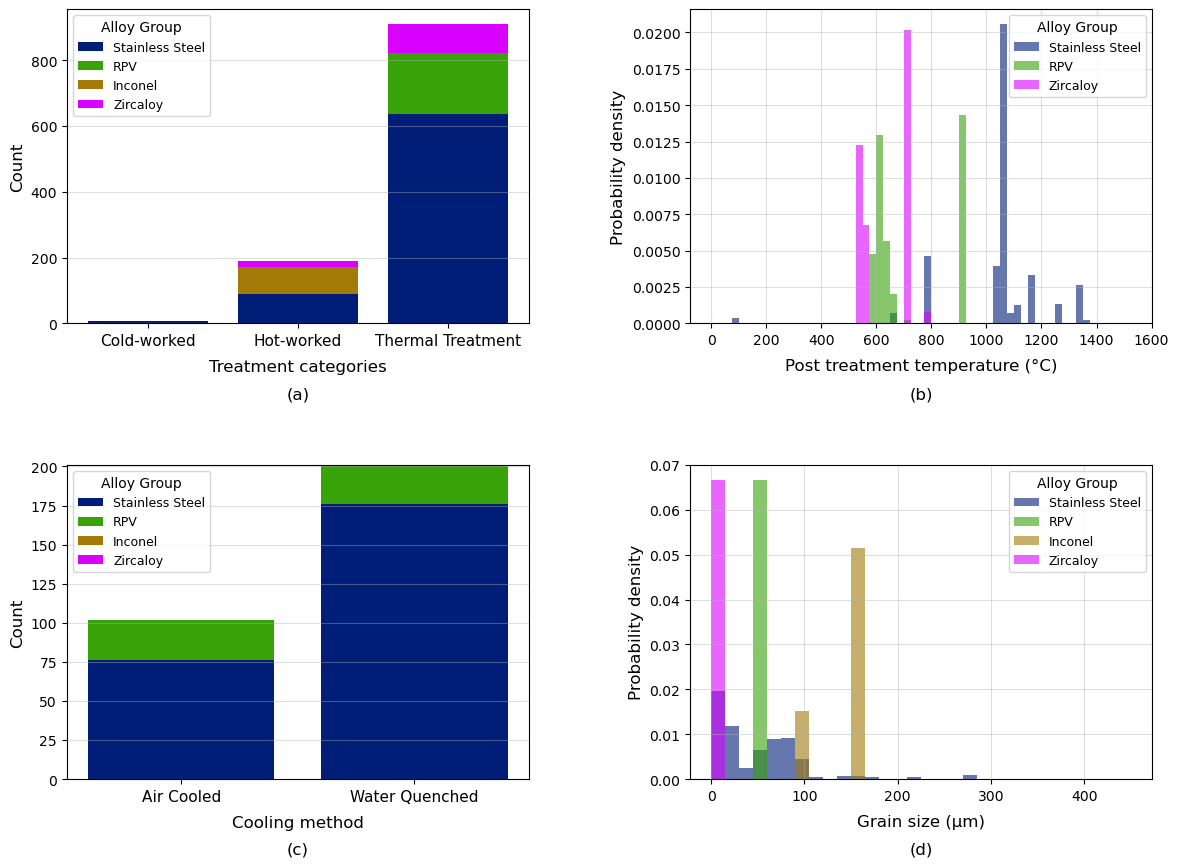

In [6]:
# Processing conditions summary (Figure 5)
group_colors = {
    'Stainless Steel': '#001D78',
    'RPV':             '#37A308',
    'Inconel':         '#A37908',
    'Zircaloy':        '#D900FF',
}
alloy_groups = ['Stainless Steel', 'RPV', 'Inconel', 'Zircaloy']
grain_col = [c for c in df.columns if 'Grain size' in c][0]

fig5, axes5 = plt.subplots(2, 2, figsize=(14, 10))
fig5.subplots_adjust(hspace=0.45, wspace=0.35)

# (a) Stacked bar: treatment categories on x-axis, alloy groups stacked
ax = axes5[0, 0]
treat_order = ['Cold-worked', 'Hot-worked', 'Thermal Treatment']
treat_data = (df.groupby(['Treatment categories', 'Alloy Group'])
                .size().unstack(fill_value=0)
                .reindex(treat_order)
                .reindex(columns=alloy_groups, fill_value=0))
x = np.arange(len(treat_order))
bottoms = np.zeros(len(treat_order))
for group in alloy_groups:
    ax.bar(x, treat_data[group].values, bottom=bottoms,
           label=group, color=group_colors[group])
    bottoms += treat_data[group].values
ax.set_xticks(x)
ax.set_xticklabels(treat_order, fontsize=11)
ax.set_xlabel('Treatment categories', fontsize=12, labelpad=8)
ax.set_ylabel('Count', fontsize=12)
ax.legend(title='Alloy Group', fontsize=9, frameon=True)
ax.grid(axis='y', alpha=0.4)
ax.text(0.5, -0.20, '(a)', transform=ax.transAxes, ha='center', va='top', fontsize=12)

# (b) Probability density of post-treatment temperature — narrow bins
ax = axes5[0, 1]
for group in alloy_groups:
    data = df[df['Alloy Group'] == group]['Post treatment temperature, C'].dropna()
    if len(data) > 1:
        ax.hist(data, bins=np.arange(0, 1550, 25), density=True, alpha=0.6,
                label=group, color=group_colors[group], edgecolor='none')
ax.set_xlabel('Post treatment temperature (\u00b0C)', fontsize=12, labelpad=8)
ax.set_ylabel('Probability density', fontsize=12)
ax.legend(title='Alloy Group', fontsize=9, frameon=True)
ax.grid(alpha=0.4)
ax.text(0.5, -0.20, '(b)', transform=ax.transAxes, ha='center', va='top', fontsize=12)

# (c) Stacked bar: cooling method on x-axis, alloy groups stacked
ax = axes5[1, 0]
cooling_order = ['Air Cooled', 'Water Quenched']
cooling_data = (df.groupby(['Cooling', 'Alloy Group'])
                  .size().unstack(fill_value=0)
                  .reindex(cooling_order)
                  .reindex(columns=alloy_groups, fill_value=0))
xc = np.arange(len(cooling_order))
bottoms = np.zeros(len(cooling_order))
for group in alloy_groups:
    ax.bar(xc, cooling_data[group].values, bottom=bottoms,
           label=group, color=group_colors[group])
    bottoms += cooling_data[group].values
ax.set_xticks(xc)
ax.set_xticklabels(cooling_order, fontsize=11)
ax.set_xlabel('Cooling method', fontsize=12, labelpad=8)
ax.set_ylabel('Count', fontsize=12)
ax.legend(title='Alloy Group', fontsize=9, frameon=True)
ax.grid(axis='y', alpha=0.4)
ax.text(0.5, -0.20, '(c)', transform=ax.transAxes, ha='center', va='top', fontsize=12)

# (d) Probability density of grain size — narrow bins
ax = axes5[1, 1]
for group in alloy_groups:
    data = df[df['Alloy Group'] == group][grain_col].dropna()
    if len(data) > 1:
        ax.hist(data, bins=np.arange(0, 460, 15), density=True, alpha=0.6,
                label=group, color=group_colors[group], edgecolor='none')
ax.set_xlabel('Grain size (\u03bcm)', fontsize=12, labelpad=8)
ax.set_ylabel('Probability density', fontsize=12)
ax.legend(title='Alloy Group', fontsize=9, frameon=True)
ax.grid(alpha=0.4)
ax.text(0.5, -0.20, '(d)', transform=ax.transAxes, ha='center', va='top', fontsize=12)

plt.savefig('Figure_5_Processing_Conditions.png', dpi=300, bbox_inches='tight')
plt.show()

## 2.4 Specimen Dimensions <a name='2.4-specimen-dimensions'></a>

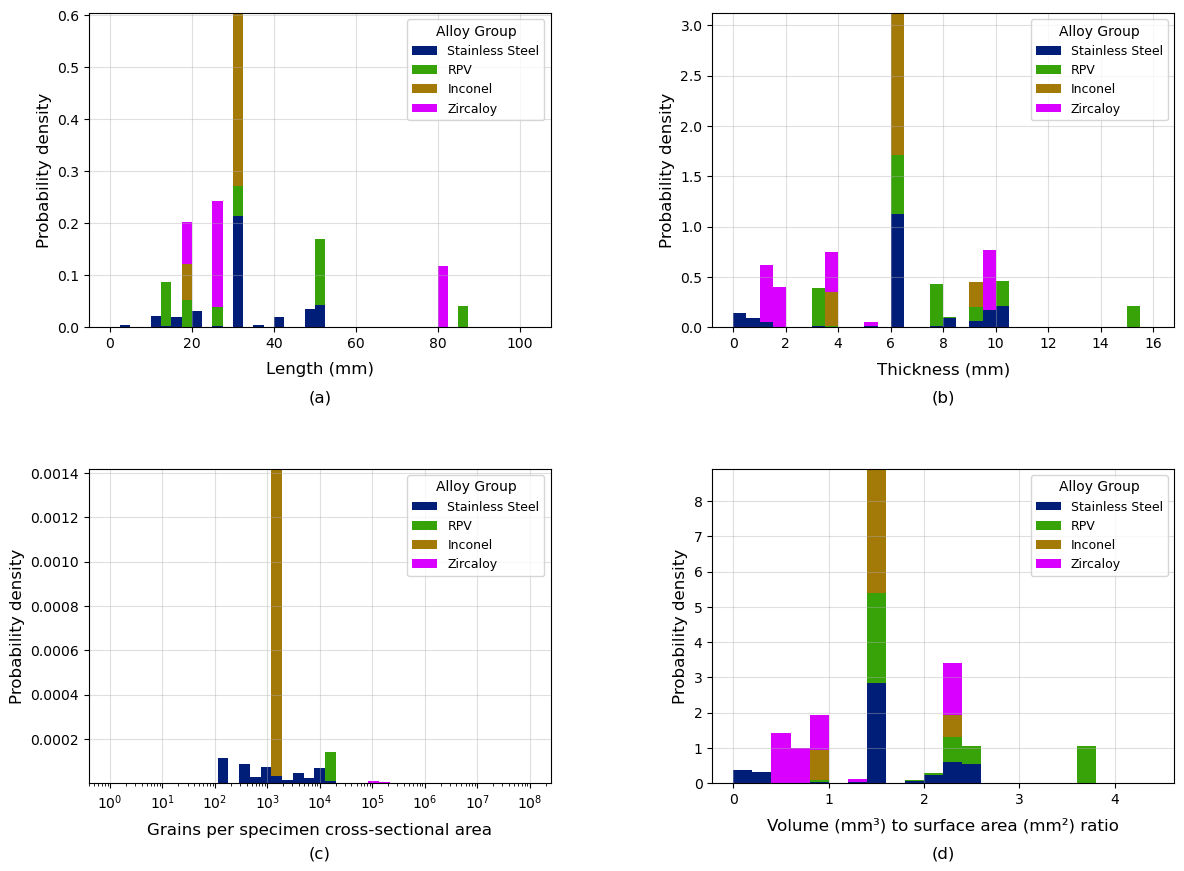

In [7]:
# Specimen dimensions summary (Figure 6)

def cross_section_area_um2(row):
    shape = row['Specimen Shape']; t = row['Thickness (mm)']; w = row['Width (mm)']
    if shape == 'Cylindrical':
        return np.pi * (t * 500.0) ** 2 if pd.notna(t) else np.nan
    return t * w * 1e6 if (pd.notna(t) and pd.notna(w)) else np.nan

def vs_ratio(row):
    shape = row['Specimen Shape']; T = row['Thickness (mm)']
    L = row['Length (mm)']; W = row['Width (mm)']
    if shape == 'Cylindrical':
        return T / 4.0 if pd.notna(T) else np.nan
    if pd.notna(T) and pd.notna(L) and pd.notna(W):
        return (L * T * W) / (2.0 * (L * T + L * W + T * W))
    return np.nan

df['A_cross_um2'] = df.apply(cross_section_area_um2, axis=1)
df['n_grains']    = df['A_cross_um2'] / df[grain_col] ** 2
df['VS_ratio']    = df.apply(vs_ratio, axis=1)

def stacked_density_hist(ax, df_in, col, alloy_groups, group_colors, bins):
    """Per-group normalised density bars stacked on top of each other."""
    bin_widths = np.diff(bins)
    bottoms = np.zeros(len(bins) - 1)
    for group in alloy_groups:
        data = df_in[df_in['Alloy Group'] == group][col].dropna().values
        if len(data) > 1:
            counts, _ = np.histogram(data, bins=bins)
            density = counts / (len(data) * bin_widths)
            ax.bar(bins[:-1], density, width=bin_widths, bottom=bottoms,
                   label=group, color=group_colors[group], align='edge', edgecolor='none')
            bottoms += density

fig6, axes6 = plt.subplots(2, 2, figsize=(14, 10))
fig6.subplots_adjust(hspace=0.45, wspace=0.35)

# (a) Gage length — stacked per-group density
ax = axes6[0, 0]
stacked_density_hist(ax, df, 'Length (mm)', alloy_groups, group_colors,
                     np.arange(0, 105, 2.5))
ax.set_xlabel('Length (mm)', fontsize=12, labelpad=8)
ax.set_ylabel('Probability density', fontsize=12)
ax.legend(title='Alloy Group', fontsize=9, frameon=True)
ax.grid(alpha=0.4)
ax.text(0.5, -0.20, '(a)', transform=ax.transAxes, ha='center', va='top', fontsize=12)

# (b) Thickness — stacked per-group density
ax = axes6[0, 1]
stacked_density_hist(ax, df, 'Thickness (mm)', alloy_groups, group_colors,
                     np.arange(0, 16.5, 0.5))
ax.set_xlabel('Thickness (mm)', fontsize=12, labelpad=8)
ax.set_ylabel('Probability density', fontsize=12)
ax.legend(title='Alloy Group', fontsize=9, frameon=True)
ax.grid(alpha=0.4)
ax.text(0.5, -0.20, '(b)', transform=ax.transAxes, ha='center', va='top', fontsize=12)

# (c) Grains per cross-sectional area — log x-axis, stacked per-group density
ax = axes6[1, 0]
df_n = df.dropna(subset=['n_grains'])
df_n = df_n[df_n['n_grains'] > 0]
bins_log = np.logspace(0, 8, 40)
bin_widths_log = np.diff(bins_log)
bottoms_log = np.zeros(len(bins_log) - 1)
for group in alloy_groups:
    data = df_n[df_n['Alloy Group'] == group]['n_grains'].dropna().values
    if len(data) > 1:
        counts, _ = np.histogram(data, bins=bins_log)
        density = counts / (len(data) * bin_widths_log)
        ax.bar(bins_log[:-1], density, width=bin_widths_log, bottom=bottoms_log,
               label=group, color=group_colors[group], align='edge', edgecolor='none')
        bottoms_log += density
ax.set_xscale('log')
ax.set_xlabel('Grains per specimen cross-sectional area', fontsize=12, labelpad=8)
ax.set_ylabel('Probability density', fontsize=12)
ax.legend(title='Alloy Group', fontsize=9, frameon=True)
ax.grid(alpha=0.4)
ax.text(0.5, -0.20, '(c)', transform=ax.transAxes, ha='center', va='top', fontsize=12)

# (d) Volume-to-surface ratio — stacked per-group density
ax = axes6[1, 1]
stacked_density_hist(ax, df, 'VS_ratio', alloy_groups, group_colors,
                     np.arange(0, 4.6, 0.2))
ax.set_xlabel('Volume (mm\u00b3) to surface area (mm\u00b2) ratio', fontsize=12, labelpad=8)
ax.set_ylabel('Probability density', fontsize=12)
ax.legend(title='Alloy Group', fontsize=9, frameon=True)
ax.grid(alpha=0.4)
ax.text(0.5, -0.20, '(d)', transform=ax.transAxes, ha='center', va='top', fontsize=12)

plt.savefig('Figure_6_Specimen_Dimensions.png', dpi=300, bbox_inches='tight')
plt.show()

## 2.5 Creep Properties – Larson-Miller Parameter <a name='2.5-creep-properties'></a>

C:\Users\avaka\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning:

divide by zero encountered in log



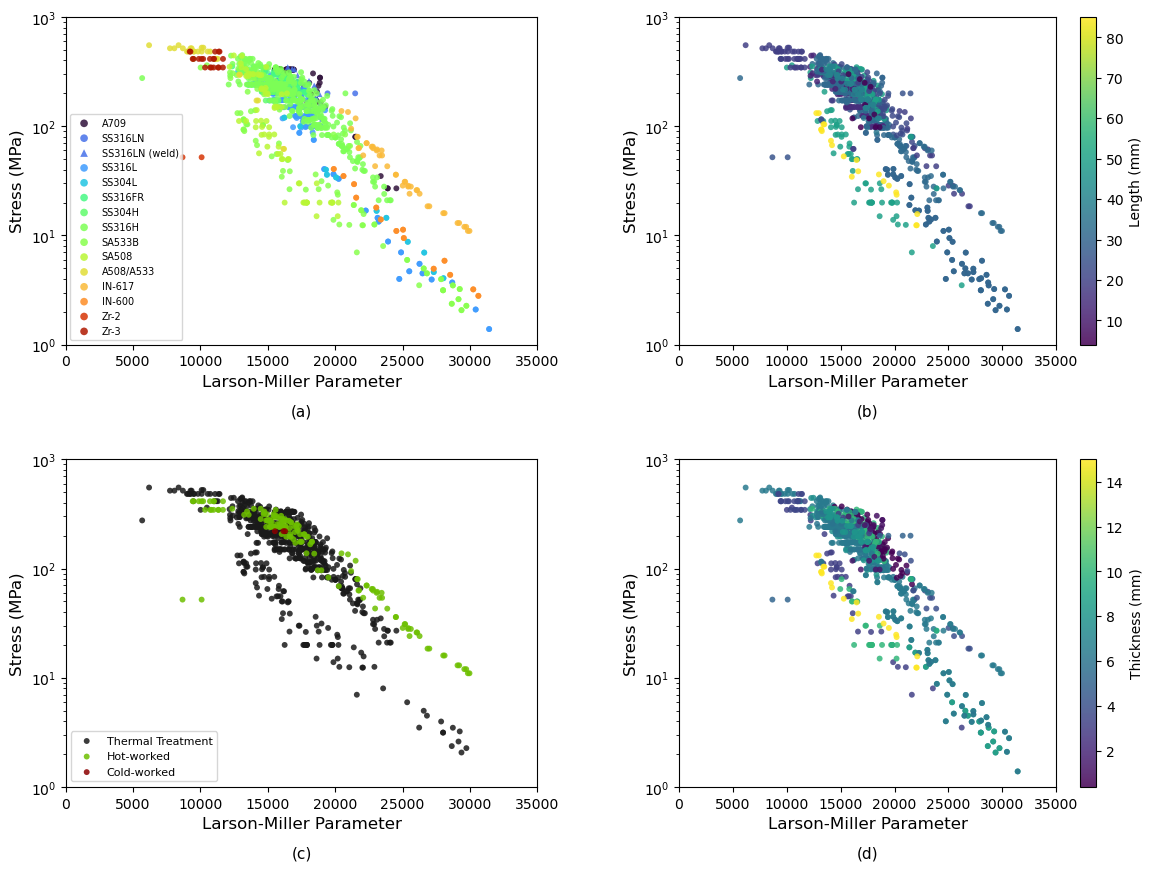

In [8]:
# Larson-Miller parameter of the collected data (Figure 7)
# LMP = Temperature_C * (20 + ln(Creep_Rupture_Life_h))
df['LMP'] = (pd.to_numeric(df['Temperature of Creep Test (C)'], errors='coerce') *
             (20 + np.log(pd.to_numeric(df['Creep Rupture Life (h)'], errors='coerce'))))
df['Stress_num']    = pd.to_numeric(df['Stress (Mpa)'],    errors='coerce')
df['Length_num']    = pd.to_numeric(df['Length (mm)'],     errors='coerce')
df['Thickness_num'] = pd.to_numeric(df['Thickness (mm)'],  errors='coerce')

df_p = df.dropna(subset=['LMP', 'Stress_num']).copy()
df_p = df_p[df_p['Creep Test Type'] != 'Small Punch']

base = plt.cm.turbo(np.linspace(0, 1, 16))
alloy_color = {
    'A709':      base[0],
    'SS316':     base[1],
    'SS316LN':   base[2],
    'SS316L':    base[3],
    'SS304L':    base[4],
    'SS316FR':   base[6],
    'SS304H':    plt.cm.turbo(6.4 / 15),
    'SS316H':    plt.cm.turbo(6.8 / 15),
    'SA533B':    base[7],
    'SA508':     base[8],
    'A508/A533': base[9],
    'IN-617':    base[10],
    'IN-600':    base[11],
    'Zr-4':      base[12],
    'Zr-2':      base[13],
    'Zr-3':      base[14],
}
plot_order = [
    'A709', 'SS316', 'SS316LN', 'SS316L', 'SS304L', 'SS316FR',
    'SS304H', 'SS316H', 'SA533B', 'SA508', 'A508/A533',
    'IN-617', 'IN-600', 'Zr-4', 'Zr-2', 'Zr-3',
]

fig7, axes7 = plt.subplots(2, 2, figsize=(14, 10))
fig7.subplots_adjust(hspace=0.35, wspace=0.3)

# (a) Alloy Designation
ax = axes7[0, 0]
for alloy in plot_order:
    if alloy == 'SS316LN':
        sub_base = df_p[(df_p['Alloy Designation'] == 'SS316LN') & (df_p['Reference'] != 22)]
        if not sub_base.empty:
            ax.scatter(sub_base['LMP'], sub_base['Stress_num'],
                       label='SS316LN', color=alloy_color['SS316LN'],
                       s=18, alpha=0.85, edgecolors='none', marker='o')
        sub_weld = df_p[(df_p['Alloy Designation'] == 'SS316LN') & (df_p['Reference'] == 22)]
        if not sub_weld.empty:
            ax.scatter(sub_weld['LMP'], sub_weld['Stress_num'],
                       label='SS316LN (weld)', color=alloy_color['SS316LN'],
                       s=18, alpha=0.85, edgecolors='none', marker='^')
    else:
        sub = df_p[df_p['Alloy Designation'] == alloy]
        if not sub.empty:
            ax.scatter(sub['LMP'], sub['Stress_num'],
                       label=alloy, color=alloy_color[alloy],
                       s=18, alpha=0.85, edgecolors='none')
ax.set_yscale('log')
ax.set_xlim(0, 35000); ax.set_ylim(1, 1000)
ax.set_xlabel('Larson-Miller Parameter', fontsize=12)
ax.set_ylabel('Stress (MPa)', fontsize=12)
ax.legend(loc='lower left', fontsize=7, frameon=True, ncol=1, markerscale=1.3)
ax.text(0.5, -0.18, '(a)', transform=ax.transAxes, ha='center', va='top', fontsize=11)

# (b) Gage length colormap
ax = axes7[0, 1]
sub_b = df_p.dropna(subset=['Length_num'])
sc = ax.scatter(sub_b['LMP'], sub_b['Stress_num'], c=sub_b['Length_num'],
                cmap='viridis', s=18, alpha=0.85, edgecolors='none')
plt.colorbar(sc, ax=ax, label='Length (mm)')
ax.set_yscale('log')
ax.set_xlim(0, 35000); ax.set_ylim(1, 1000)
ax.set_xlabel('Larson-Miller Parameter', fontsize=12)
ax.set_ylabel('Stress (MPa)', fontsize=12)
ax.text(0.5, -0.18, '(b)', transform=ax.transAxes, ha='center', va='top', fontsize=11)

# (c) Treatment categories
ax = axes7[1, 0]
treat_colors_lmp = {
    'Thermal Treatment': '#1a1a1a',
    'Hot-worked':        '#6dbf00',
    'Cold-worked':       '#8b0000',
}
for treat, color in treat_colors_lmp.items():
    sub_c = df_p[df_p['Treatment categories'] == treat]
    ax.scatter(sub_c['LMP'], sub_c['Stress_num'], label=treat,
               color=color, s=18, alpha=0.85, edgecolors='none')
ax.set_yscale('log')
ax.set_xlim(0, 35000); ax.set_ylim(1, 1000)
ax.set_xlabel('Larson-Miller Parameter', fontsize=12)
ax.set_ylabel('Stress (MPa)', fontsize=12)
ax.legend(loc='lower left', fontsize=8, frameon=True)
ax.text(0.5, -0.18, '(c)', transform=ax.transAxes, ha='center', va='top', fontsize=11)

# (d) Thickness colormap
ax = axes7[1, 1]
sub_d = df_p.dropna(subset=['Thickness_num'])
sc2 = ax.scatter(sub_d['LMP'], sub_d['Stress_num'], c=sub_d['Thickness_num'],
                 cmap='viridis', s=18, alpha=0.85, edgecolors='none')
plt.colorbar(sc2, ax=ax, label='Thickness (mm)')
ax.set_yscale('log')
ax.set_xlim(0, 35000); ax.set_ylim(1, 1000)
ax.set_xlabel('Larson-Miller Parameter', fontsize=12)
ax.set_ylabel('Stress (MPa)', fontsize=12)
ax.text(0.5, -0.18, '(d)', transform=ax.transAxes, ha='center', va='top', fontsize=11)

plt.savefig('Figure_7_Larson_Miller_Parameter.png', dpi=300, bbox_inches='tight')
plt.show()